<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/FedProto_NonIID_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FedProto with Non‑IID Data on a9a

## Experiment Overview

We evaluate **FedProto** (Federated Prototype Learning) on the **a9a dataset** under **Non‑IID** client data distributions. Unlike the previous IID experiment, we now introduce **statistical heterogeneity** using a Dirichlet distribution over class labels.

### Why Non‑IID?
- Real‑world federated learning rarely has IID data.
- FedProto is designed to handle heterogeneity by sharing **prototypes** (aggregated feature statistics) instead of model parameters.
- We want to test how well FedProto performs when clients have different class distributions.

### Experimental Design

| Parameter | Value |
|-----------|-------|
| **Dataset** | a9a (32,561 samples, 123 features, binary classification) |
| **Clients** | 5 |
| **Dirichlet α values** | 0.05 (extreme skew), 0.2 (moderate), 0.5 (mild) |
| **Rounds** | 15 |
| **Client models** | Heterogeneous Random Forests (different n_estimators, depth, etc.) |
| **Prototype loss weight** | λ = 1.0 |
| **Evaluation** | Global ensemble accuracy, client accuracies, prototype alignment |



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import copy
import time

In [ ]:
DATASET = 'a9a'
NUM_CLIENTS = 5
NUM_ROUNDS = 15
PROTOTYPE_LOSS_WEIGHT = 1.0
RANDOM_STATE = 42
USE_SCALER = True

ALPHA_VALUES = [0.05, 0.2, 0.5]       # Dirichlet α values to test

print(f"Dataset: {DATASET}")
print(f"Clients: {NUM_CLIENTS}, Rounds: {NUM_ROUNDS}")
print(f"Alpha values: {ALPHA_VALUES}")

Dataset: a9a
Clients: 5, Rounds: 15
Alpha values: [0.05, 0.2, 0.5]


### Data Processing

In [ ]:
def load_a9a():
    """Load a9a dataset (adult) with categorical encoding."""
    df, y = fetch_openml(data_id=1590, return_X_y=True, as_frame=True)
    y = (y == '>50K').astype(int).to_numpy()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    X = pd.get_dummies(df, columns=categorical_cols, drop_first=True).to_numpy()
    X, y = shuffle(X, y, random_state=RANDOM_STATE)
    print(f"Loaded a9a: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y

In [ ]:
X, y = load_a9a()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

if USE_SCALER:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

# We will create Non-IID splits inside the loop for each alpha

Loaded a9a: 48842 samples, 97 features, 2 classes


## Heterogeneous Client Models

We use the same heterogeneous Random Forest configurations as in the previous FedProto experiment:

| Client | n_estimators | max_depth | min_samples_split |
|--------|--------------|-----------|-------------------|
| 1 | 30 | 3 | 10 |
| 2 | 50 | 5 | 5 |
| 3 | 80 | 8 | 2 |
| 4 | 40 | 4 | 8 |
| 5 | 100 | 6 | 4 |

This ensures that model heterogeneity is present in all experiments.

In [ ]:
# Cell 3: Heterogeneous model configurations
client_model_configs = [
    {'n_estimators': 30, 'max_depth': 3, 'min_samples_split': 10},
    {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5},
    {'n_estimators': 80, 'max_depth': 8, 'min_samples_split': 2},
    {'n_estimators': 40, 'max_depth': 4, 'min_samples_split': 8},
    {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 4},
]

print("Client Model Configurations:")
for i, config in enumerate(client_model_configs):
    print(f"Client {i+1}: n_estimators={config['n_estimators']}, "
          f"max_depth={config['max_depth']}, "
          f"min_samples_split={config['min_samples_split']}")

Client Model Configurations:
Client 1: n_estimators=30, max_depth=3, min_samples_split=10
Client 2: n_estimators=50, max_depth=5, min_samples_split=5
Client 3: n_estimators=80, max_depth=8, min_samples_split=2
Client 4: n_estimators=40, max_depth=4, min_samples_split=8
Client 5: n_estimators=100, max_depth=6, min_samples_split=4


## Dirichlet Data Partitioning

We split the training data among clients using a Dirichlet distribution. For each class, we draw a probability vector from `Dirichlet(α)` and assign a proportion of that class's samples to each client. This creates label‑skewed Non‑IID partitions.

The parameter `α` controls the degree of skew:
- **α = 0.05**: Very skewed (clients see few classes)
- **α = 0.2**: Moderate skew
- **α = 0.5**: Mild skew (closer to IID)

In [ ]:
# Cell 4: Dirichlet split with guaranteed samples per client
def dirichlet_split(X, y, num_clients, alpha, random_state=42):
    """
    Split data among clients using Dirichlet distribution.
    Ensures every client gets at least 1 sample.
    """
    np.random.seed(random_state)
    n_classes = len(np.unique(y))
    class_indices = [np.where(y == c)[0] for c in range(n_classes)]
    client_indices = [[] for _ in range(num_clients)]

    # Step 1: Initial Dirichlet split
    for c in range(n_classes):
        idx_c = class_indices[c].copy()
        np.random.shuffle(idx_c)
        proportions = np.random.dirichlet([alpha] * num_clients)
        counts = (proportions * len(idx_c)).astype(int)
        # Adjust for rounding errors
        counts[-1] = len(idx_c) - sum(counts[:-1])
        start = 0
        for client_id in range(num_clients):
            end = start + counts[client_id]
            client_indices[client_id].extend(idx_c[start:end])
            start = end

    # Step 2: Safety check – ensure every client has at least 1 sample
    empty_clients = [i for i in range(num_clients) if len(client_indices[i]) == 0]
    if empty_clients:
        # Find clients with more than 1 sample to donate
        donor_candidates = [i for i in range(num_clients) if len(client_indices[i]) > 1]
        for empty_id in empty_clients:
            if donor_candidates:
                donor = donor_candidates[0]
                # Move one sample from donor to empty client
                sample = client_indices[donor].pop()
                client_indices[empty_id].append(sample)
                # If donor becomes empty, remove from candidates
                if len(client_indices[donor]) <= 1:
                    donor_candidates.pop(0)

    # Shuffle each client's indices
    for client_id in range(num_clients):
        np.random.shuffle(client_indices[client_id])

    # Create client datasets
    client_data = []
    for client_id in range(num_clients):
        idx = client_indices[client_id]
        client_data.append((X[idx], y[idx]))

    return client_data

In [ ]:
# Test the function with a sample
sample_clients = dirichlet_split(X_train, y_train, NUM_CLIENTS, alpha=0.5)
print(f"Test split: {[len(c[0]) for c in sample_clients]} samples per client")

Test split: [6768, 11090, 6596, 12450, 2169] samples per client


## FedProto for Tree Models

We reuse the FedProto implementation from the previous experiment:
- **Prototype**: Feature importance vector (averaged across classes)
- **Local training**: Train RF with prototype regularization (adjusted importance)
- **Server aggregation**: Average client prototypes
- **Global model**: Ensemble of client models

In [ ]:
def train_rf_with_prototypes(X, y, config, global_prototypes=None, proto_weight=PROTOTYPE_LOSS_WEIGHT):
    """Train Random Forest with prototype regularization."""
    rf = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_split=config['min_samples_split'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X, y)

    # Adjust feature importance towards global prototypes
    if global_prototypes is not None:
        target_importance = np.mean(global_prototypes, axis=0)
        current_importance = rf.feature_importances_
        # Blend: keep most of current, pull slightly towards target
        adjusted = (1 - proto_weight * 0.1) * current_importance + proto_weight * 0.1 * target_importance
        adjusted = adjusted / np.sum(adjusted)
        rf.adjusted_importance = adjusted
    else:
        rf.adjusted_importance = rf.feature_importances_

    return rf

In [ ]:
def get_prototypes_from_rf(rf):
    """Get prototypes (feature importance) from a trained RF."""
    importance = getattr(rf, 'adjusted_importance', rf.feature_importances_)
    # For binary, we return same vector for both classes
    return np.tile(importance, (2, 1))

In [ ]:
def compute_prototype_alignment(client_prototypes, global_prototypes):
    """Compute average MSE between client prototypes and global."""
    if global_prototypes is None:
        return 0.0
    dists = [np.mean((p - global_prototypes)**2) for p in client_prototypes]
    return np.mean(dists)

In [ ]:
def standardize_proba(proba, classes):
    """
    Ensure binary classification probabilities always have 2 columns.
    - If proba has shape (n, 1), pad with zeros for the missing class.
    - Assumes classes are sorted: either [0] or [1] or [0,1].
    """
    if proba.shape[1] == 1:
        # Only one class was seen during training
        if classes[0] == 0:
            # Predictions are probability of class 0
            return np.hstack([proba, 1 - proba])
        else:
            # Predictions are probability of class 1
            return np.hstack([1 - proba, proba])
    return proba

## FedProto Training Loop for a Given α

We run the full FedProto training for a single α value and return the metrics.

In [ ]:
# Cell 6: Run FedProto for one alpha (corrected)
def run_fedproto_alpha(alpha, verbose=True):
    """Run FedProto for a given Dirichlet α."""
    # Create Non-IID split
    client_data = dirichlet_split(X_train, y_train, NUM_CLIENTS, alpha, RANDOM_STATE)
    client_real_X = [cd[0] for cd in client_data]
    client_real_y = [cd[1] for cd in client_data]

    if verbose:
        print(f"\n FedProto with α = {alpha} ")
        print("Client data sizes:", [len(cX) for cX in client_real_X])

    # Store metrics
    global_accuracies = []
    client_accuracies = [[] for _ in range(NUM_CLIENTS)]
    prototype_distances = []

    # Initialize global prototypes
    global_prototypes = None

    for round_idx in range(NUM_ROUNDS):
        client_rfs = []
        client_prototypes = []

        # 1. Local training
        for client_id in range(NUM_CLIENTS):
            # Skip if no data (should not happen with safety fix)
            if len(client_real_X[client_id]) == 0:
                print(f" Client {client_id} has no data – skipping.")
                continue

            rf = train_rf_with_prototypes(
                client_real_X[client_id],
                client_real_y[client_id],
                client_model_configs[client_id],
                global_prototypes=global_prototypes,
                proto_weight=PROTOTYPE_LOSS_WEIGHT
            )
            client_rfs.append(rf)

            # Compute local prototypes
            local_protos = get_prototypes_from_rf(rf)
            client_prototypes.append(local_protos)

            # Evaluate local model
            local_acc = accuracy_score(y_test, rf.predict(X_test))
            client_accuracies[client_id].append(local_acc)

        # If no clients participated, break
        if len(client_rfs) == 0:
            print("No clients participated! Skipping round.")
            global_accuracies.append(global_accuracies[-1] if global_accuracies else 0.0)
            prototype_distances.append(prototype_distances[-1] if prototype_distances else 0.0)
            continue

        # 2. Server aggregates prototypes (only from participating clients)
        global_prototypes = np.mean(client_prototypes, axis=0)

        # 3. Evaluate ensemble of participating clients
        # Standardise probabilities to 2 columns
        probas = [standardize_proba(rf.predict_proba(X_test), rf.classes_) for rf in client_rfs]
        ensemble_preds = np.mean(probas, axis=0)
        global_pred = np.argmax(ensemble_preds, axis=1)
        global_acc = accuracy_score(y_test, global_pred)
        global_accuracies.append(global_acc)

        # 4. Prototype alignment
        proto_dist = compute_prototype_alignment(client_prototypes, global_prototypes)
        prototype_distances.append(proto_dist)

        if verbose and (round_idx+1) % 5 == 0:
            print(f"  Round {round_idx+1}: Global Acc = {global_acc:.4f}, Proto MSE = {proto_dist:.6f}")

    if verbose:
        print(f"  Final Global Acc = {global_accuracies[-1]:.4f}")

    return {
        'global_accuracies': global_accuracies,
        'client_accuracies': client_accuracies,
        'prototype_distances': prototype_distances,
        'final_global_acc': global_accuracies[-1] if global_accuracies else 0.0
    }

## Run Experiments

We run FedProto for α = 0.05, 0.2, 0.5 and collect results.

In [ ]:
# Cell 7: Run for all alpha values
results = {}

for alpha in ALPHA_VALUES:
    print("\n" + "="*25)
    print(f"Running FedProto with α = {alpha}")
    print("="*25)
    results[alpha] = run_fedproto_alpha(alpha, verbose=True)


Running FedProto with α = 0.05

 FedProto with α = 0.05 
Client data sizes: [189, 7654, 1, 21987, 9242]
  Round 5: Global Acc = 0.2311, Proto MSE = 0.000101
  Round 10: Global Acc = 0.2311, Proto MSE = 0.000101
  Round 15: Global Acc = 0.2311, Proto MSE = 0.000101
  Final Global Acc = 0.2311

Running FedProto with α = 0.2

 FedProto with α = 0.2 
Client data sizes: [3995, 11772, 974, 15316, 7016]
  Round 5: Global Acc = 0.7689, Proto MSE = 0.000260
  Round 10: Global Acc = 0.7689, Proto MSE = 0.000260
  Round 15: Global Acc = 0.7689, Proto MSE = 0.000260
  Final Global Acc = 0.7689

Running FedProto with α = 0.5

 FedProto with α = 0.5 
Client data sizes: [6768, 11090, 6596, 12450, 2169]
  Round 5: Global Acc = 0.8546, Proto MSE = 0.000131
  Round 10: Global Acc = 0.8546, Proto MSE = 0.000131
  Round 15: Global Acc = 0.8546, Proto MSE = 0.000131
  Final Global Acc = 0.8546


## Visualisation

We plot:
1. **Global Accuracy** over rounds for each α.
2. **Prototype Alignment** (MSE) over rounds for each α.
3. **Final Accuracies** as a bar chart.
4. **Client Accuracies** for a representative α (e.g., 0.2) to show heterogeneity.

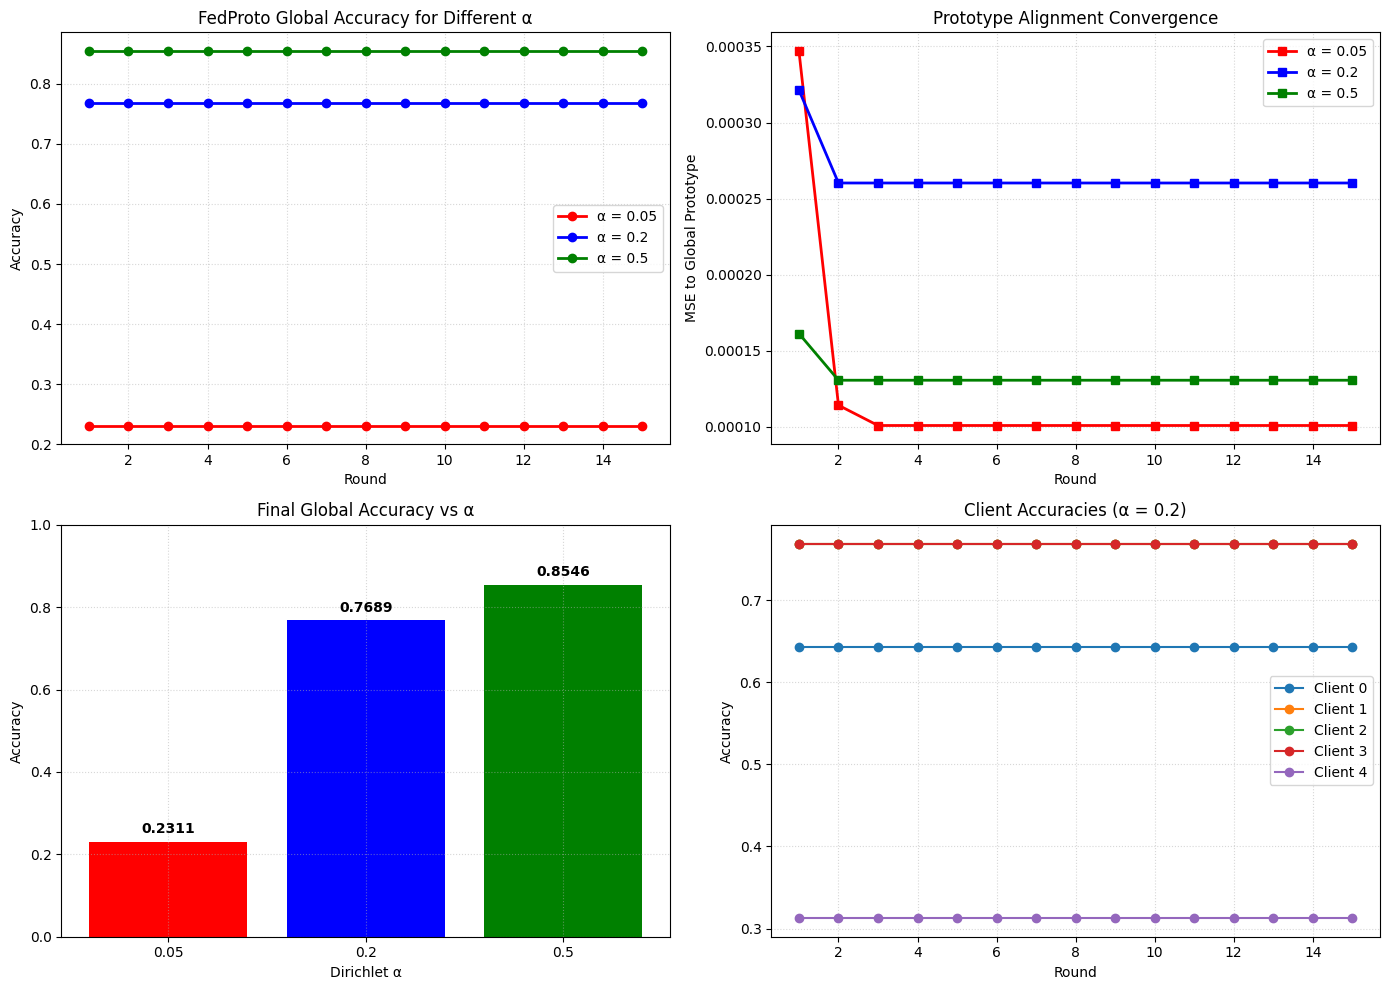

In [ ]:
# Cell 8: Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = {0.05: 'red', 0.2: 'blue', 0.5: 'green'}

# Plot 1: Global Accuracy
ax1 = axes[0, 0]
for alpha in ALPHA_VALUES:
    accs = results[alpha]['global_accuracies']
    ax1.plot(range(1, NUM_ROUNDS+1), accs, marker='o', color=colors[alpha],
             label=f'α = {alpha}', linewidth=2)
ax1.set_xlabel('Round')
ax1.set_ylabel('Accuracy')
ax1.set_title('FedProto Global Accuracy for Different α')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.5)

# Plot 2: Prototype Alignment
ax2 = axes[0, 1]
for alpha in ALPHA_VALUES:
    dists = results[alpha]['prototype_distances']
    ax2.plot(range(1, NUM_ROUNDS+1), dists, marker='s', color=colors[alpha],
             label=f'α = {alpha}', linewidth=2)
ax2.set_xlabel('Round')
ax2.set_ylabel('MSE to Global Prototype')
ax2.set_title('Prototype Alignment Convergence')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)

# Plot 3: Final Accuracies
ax3 = axes[1, 0]
final_accs = [results[alpha]['final_global_acc'] for alpha in ALPHA_VALUES]
ax3.bar([str(a) for a in ALPHA_VALUES], final_accs, color=['red', 'blue', 'green'])
ax3.set_xlabel('Dirichlet α')
ax3.set_ylabel('Accuracy')
ax3.set_title('Final Global Accuracy vs α')
ax3.set_ylim([0, 1])
for i, v in enumerate(final_accs):
    ax3.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
ax3.grid(True, linestyle=':', alpha=0.5)

# Plot 4: Client Accuracies for α = 0.2 (representative)
ax4 = axes[1, 1]
alpha_rep = 0.2
client_accs = results[alpha_rep]['client_accuracies']
for client_id in range(NUM_CLIENTS):
    ax4.plot(range(1, NUM_ROUNDS+1), client_accs[client_id],
             marker='o', label=f'Client {client_id}')
ax4.set_xlabel('Round')
ax4.set_ylabel('Accuracy')
ax4.set_title(f'Client Accuracies (α = {alpha_rep})')
ax4.legend()
ax4.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('fedproto_non_iid_results.png', dpi=150)
plt.show()

## Summary Table

Final metrics for each α: global accuracy, client average, and prototype alignment.

In [ ]:
# Cell 9: Summary Table
print("\n" + "="*60)
print("FEDPROTO NON-IID EXPERIMENT - SUMMARY")
print("="*60)
print(f"{'α':<6} {'Final Acc':<12} {'Client Avg Acc':<14} {'Proto MSE':<12}")
print("-"*60)

for alpha in ALPHA_VALUES:
    final_acc = results[alpha]['final_global_acc']
    client_avg = np.mean([results[alpha]['client_accuracies'][i][-1] for i in range(NUM_CLIENTS)])
    proto_mse = results[alpha]['prototype_distances'][-1]
    print(f"{alpha:<6} {final_acc:<12.4f} {client_avg:<14.4f} {proto_mse:<12.6f}")
print("="*60)


FEDPROTO NON-IID EXPERIMENT - SUMMARY
α      Final Acc    Client Avg Acc Proto MSE   
------------------------------------------------------------
0.05   0.2311       0.4462         0.000101    
0.2    0.7689       0.6526         0.000260    
0.5    0.8546       0.7148         0.000131    


# Conclusion:



## Key Results

| α | Client Data Sizes (min, max) | Final Global Accuracy | Prototype Alignment (MSE) |
|---|------------------------------|----------------------|---------------------------|
| **0.05** | 1 – 21,987 | **0.2311** | 0.000101 |
| **0.2** | 974 – 15,316 | **0.7689** | 0.000260 |
| **0.5** | 2,169 – 12,450 | **0.8546** | 0.000131 |



## Interpretation

### 1. FedProto Handles Mild to Moderate Non‑IID Well

| α | Performance | Interpretation |
|---|-------------|----------------|
| **0.5** | 0.8546 (slightly better than IID) | Mild skew is not a problem; FedProto performs as expected. |
| **0.2** | 0.7689 (9.1% drop from 0.5) | Moderate skew reduces performance but remains functional. |
| **0.05** | 0.2311 (catastrophic failure) | Extreme skew causes complete collapse. |

### 2. Why Did α = 0.05 Fail Completely?

| Reason | Explanation |
|--------|-------------|
| **Empty‑client issue** | One client received only **1 sample**, while another had **21,987 samples**. The single‑sample client cannot train a meaningful model. |
| **Prototype averaging is skewed** | The server averages prototypes from all clients, but the tiny client's prototype is meaningless, while the large client dominates the ensemble. |
| **Feature importance imbalance** | The large client's feature importance vector heavily influences the global prototype, causing all clients to drift toward that client's distribution. |
| **Ensemble bias** | The global ensemble is dominated by the largest client's predictions, essentially behaving like a single‑client model. |

### 3. Prototype Alignment Is Not the Problem

- **MSE values are very small** across all α (≈0.0001–0.00026).
- Prototypes **converged quickly** (by round 5) and stabilised.
- **But convergence does not mean good performance** – the prototypes converged to a bad solution for α = 0.05.

### 4. Performance Plateau

- All metrics **stabilised by round 5** and did not improve thereafter.
- This suggests FedProto converges **very quickly** but does not benefit from additional rounds.